# Market-Implied Default Probabilities: Five U.S. Bank Holding Companies

Calibrates `creditlib` to indicative 5-year senior CDS spreads for JPM, BAC, USB, WFC and C,
and sets the market-implied credit ordering against a fundamental one.

## Read this before reading the charts

**One quote per name is not a term structure.** Each name supplies a single 5Y spread, so the
bootstrap has exactly one degree of freedom and returns a *flat* hazard rate. Every point on the
PD curves away from 5Y is the piecewise-flat assumption, not market information. The charts mark
the 5Y point as observed and render everything else dashed. Nothing in the writeup claims a term
structure. Obtaining 1/3/5/7/10Y quotes per name would produce a real one — the engine already
handles it (see `tests/test_bootstrap.py`); the constraint is data, not model.

**These are risk-neutral probabilities.** They embed a default risk premium, a liquidity premium
and correlation/systemic compensation. They run roughly 8–12x historical actuarial default rates
for comparable ratings. Do not read "Citigroup has a 6.8% chance of defaulting."

**Spreads are indicative.** Post-2014 single-name U.S. bank CDS is materially less liquid than
pre-crisis, with much of the flow in CDX.NA.IG. Bid/ask on these names is plausibly wide enough
that 4–5bp gaps between adjacent names are not reliably tradeable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from creditlib import DiscountCurve, bootstrap_survival_curve

SPREADS = {
    "JPMorgan":        0.0058,
    "Bank of America": 0.0063,
    "U.S. Bancorp":    0.0067,
    "Wells Fargo":     0.0072,
    "Citigroup":       0.0085,
}
RECOVERY = 0.40

## Why 40% recovery — and why it is the weakest input here

40% is the **ISDA quoting convention** for senior unsecured obligations of developed-market
corporates. It is a market standard that makes quotes comparable. It is *not* an estimate of what
these instruments would recover.

For U.S. bank holding companies specifically the convention is doing more work than usual:

1. **Holdco senior is the bail-in layer.** Single-name CDS on U.S. banks references the *holding
   company*. Under Dodd-Frank Title II Orderly Liquidation Authority and the single-point-of-entry
   resolution strategy, holdco senior unsecured is explicitly TLAC — it exists to be written down
   or converted so the operating subsidiaries continue. Its recovery in the scenario that triggers
   a CDS credit event is by design low, not the corporate-average 40%.

2. **The one clean data point is 8.625%.** Lehman Brothers senior CDS settled at 8.625 cents in
   the October 2008 auction. That is the only large-bank senior auction in the modern era, and it
   came in at roughly a fifth of the convention.

3. **The empirical base is thin.** Bank senior recoveries are governed by resolution mechanics
   that have never been tested at scale on a U.S. G-SIB. There is no well-populated distribution
   to average.

Practically: 40% is defensible **as a convention**, and it is the right choice for consistency
with how the quotes were formed. It is not defensible as a forecast. The sensitivity section
quantifies exactly how much it matters — and, importantly, how much it does *not*.

In [2]:
# Illustrative USD OIS-style discount curve.
# CDS-implied PD is nearly insensitive to it (Step 4: IR DV01 was 0.14% of CS01);
# that insensitivity is demonstrated below rather than asserted.
discount = DiscountCurve.from_zero_rates(
    [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0],
    [0.0430, 0.0421, 0.0402, 0.0381, 0.0374, 0.0372, 0.0378, 0.0390],
)

curves, rows = {}, []
for name, s in SPREADS.items():
    res = bootstrap_survival_curve({5.0: s}, discount, RECOVERY)
    curves[name] = res.curve
    rows.append({
        "Name": name,
        "5Y spread (bp)": s * 1e4,
        "Implied hazard (bp)": res.hazards[0] * 1e4,
        "1Y PD": 1 - float(res.curve.survival(1.0)),
        "5Y PD": 1 - float(res.curve.survival(5.0)),
        "10Y PD": 1 - float(res.curve.survival(10.0)),
        "Reprice err (bp)": res.max_abs_error_bp,
    })

implied = pd.DataFrame(rows)
implied.style.format({
    "5Y spread (bp)": "{:.0f}", "Implied hazard (bp)": "{:.1f}",
    "1Y PD": "{:.2%}", "5Y PD": "{:.2%}", "10Y PD": "{:.2%}",
    "Reprice err (bp)": "{:.1e}",
})

,Name,5Y spread (bp),Implied hazard (bp),1Y PD,5Y PD,10Y PD,Reprice err (bp)
0,JPMorgan,58,96.2,0.96%,4.70%,9.17%,1.5e-13
1,Bank of America,63,104.5,1.04%,5.09%,9.92%,8.7e-14
2,U.S. Bancorp,67,111.1,1.11%,5.41%,10.52%,8.7e-15
3,Wells Fargo,72,119.4,1.19%,5.80%,11.26%,2.6e-14
4,Citigroup,85,141.0,1.40%,6.81%,13.15%,5.2e-14


Repricing error is zero to machine precision — one quote, one knot, a square system. That is a
check that the calibration is exact, not evidence the model is right.

In [3]:
rng = implied["5Y PD"]
print(f"Spread dispersion : {implied['5Y spread (bp)'].min():.0f}-{implied['5Y spread (bp)'].max():.0f}bp "
      f"({implied['5Y spread (bp)'].max() - implied['5Y spread (bp)'].min():.0f}bp total)")
print(f"5Y PD dispersion  : {rng.min():.2%}-{rng.max():.2%} ({(rng.max()-rng.min())*100:.2f}pp total)")
print(f"JPM -> BAC        : {(rng.iloc[1]-rng.iloc[0])*100:.3f}pp of PD on a 5bp spread gap")
print(f"BAC -> USB        : {(rng.iloc[2]-rng.iloc[1])*100:.3f}pp of PD on a 4bp spread gap")

Spread dispersion : 58-85bp (27bp total)
5Y PD dispersion  : 4.70%-6.81% (2.11pp total)
JPM -> BAC        : 0.394pp of PD on a 5bp spread gap
BAC -> USB        : 0.314pp of PD on a 4bp spread gap


**The entire cross-sectional signal is 27bp.** The three tightest names sit inside 9bp of each
other. Whether JPM, BAC and USB are genuinely distinguishable on this data is a question about
bid/ask, not about credit.

In [4]:
# Discount curve barely matters -- shown, not asserted.
for z in (0.01, 0.0372, 0.07):
    pd5 = 1 - float(bootstrap_survival_curve(
        {5.0: SPREADS["Citigroup"]}, DiscountCurve.flat(z), RECOVERY).curve.survival(5.0))
    print(f"flat {z:.2%} discount curve -> Citigroup 5Y PD = {pd5:.4%}")

flat 1.00% discount curve -> Citigroup 5Y PD = 6.8300%
flat 3.72% discount curve -> Citigroup 5Y PD = 6.8077%
flat 7.00% discount curve -> Citigroup 5Y PD = 6.7807%


A 600bp swing in the discount curve moves implied 5Y PD by 5bp of probability. The rates input is
not where the uncertainty lives. The recovery input is.

In [5]:
RECS = [0.40, 0.25, 0.10, 0.086]   # convention / stressed resolution / severe / Lehman auction
sens = pd.DataFrame(
    {f"R={r:.1%}": [1 - float(bootstrap_survival_curve({5.0: s}, discount, r).curve.survival(5.0))
                    for s in SPREADS.values()] for r in RECS},
    index=list(SPREADS),
)
sens.style.format("{:.2%}")

,R=40.0%,R=25.0%,R=10.0%,R=8.6%
JPMorgan,4.70%,3.78%,3.16%,3.11%
Bank of America,5.09%,4.09%,3.42%,3.37%
U.S. Bancorp,5.41%,4.35%,3.64%,3.58%
Wells Fargo,5.80%,4.67%,3.90%,3.84%
Citigroup,6.81%,5.48%,4.59%,4.52%


In [6]:
# Uniform R is a monotone transform of the spread, so it cannot reorder the names.
# Differentiated R can. What differential would it take?
h_jpm = SPREADS["JPMorgan"] / (1 - RECOVERY)
print("Recovery at which each name's implied PD ties JPMorgan at R=40%:\n")
for n in list(SPREADS)[1:]:
    print(f"  {n:16s} {1 - SPREADS[n]/h_jpm:6.2%}")

Recovery at which each name's implied PD ties JPMorgan at R=40%:

  Bank of America  34.83%
  U.S. Bancorp     30.69%
  Wells Fargo      25.52%
  Citigroup        12.07%


This is the analytically load-bearing result of the recovery discussion:

- With **one recovery for all five names**, $h = s/(1-R)$ is a monotone transform of the spread.
  The ranking is *invariant*. Recovery moves levels only.
- With **name-specific recovery**, the ranking can reorder — but the required differential is
  large. Citigroup only ties JPMorgan if you assume Citi recovers **12%** while JPM recovers 40%,
  a 28-point differential.

So: the ordering below is robust to the weakest input in the model. The absolute probabilities
are not. State the ordering with confidence; state the levels with a recovery caveat attached.

In [7]:
# Historical issuer-weighted cumulative 5y default rates (Moody's, approx. 1983-2023).
# VERIFY against the current Moody's Annual Default Study before citing externally.
ACTUARIAL = {"Aa": 0.0031, "A": 0.0056, "Baa": 0.0155}
for k, v in ACTUARIAL.items():
    print(f"{k}-rated 5Y cumulative default rate (historical): {v:.2%}")
print(f"\nMarket-implied range: {rng.min():.2%} - {rng.max():.2%}")
print(f"Ratio to A-rated actuarial: {rng.min()/ACTUARIAL['A']:.1f}x - {rng.max()/ACTUARIAL['A']:.1f}x")

Aa-rated 5Y cumulative default rate (historical): 0.31%
A-rated 5Y cumulative default rate (historical): 0.56%
Baa-rated 5Y cumulative default rate (historical): 1.55%

Market-implied range: 4.70% - 6.81%
Ratio to A-rated actuarial: 8.4x - 12.2x


Roughly an order of magnitude above realised default experience. That wedge is the risk premium —
compensation for jump-to-default, illiquidity, and the fact that bank defaults arrive correlated
with everything else in a portfolio. It is not a forecast error, and it is why risk-neutral PD is
a *pricing* quantity, not an *actuarial* one.

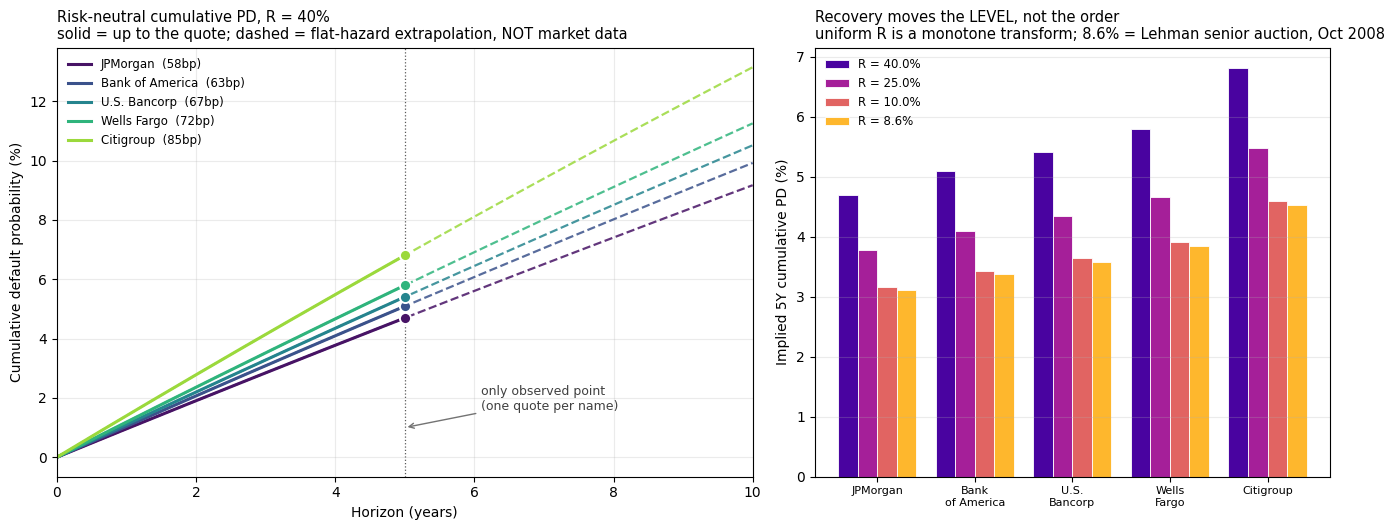

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(SPREADS)))
t = np.linspace(0, 10, 400)

for (name, cc), c in zip(curves.items(), colors):
    pdv = 1 - np.asarray(cc.survival(t))
    ax1.plot(t, pdv * 100, ls="--", lw=1.6, color=c, alpha=0.85)
    ax1.plot(t[t <= 5], pdv[t <= 5] * 100, lw=2.2, color=c,
             label=f"{name}  ({SPREADS[name]*1e4:.0f}bp)")
    ax1.plot(5.0, (1 - float(cc.survival(5.0))) * 100, "o", ms=8, color=c, mec="white", mew=1.4, zorder=5)

ax1.axvline(5.0, color="0.35", lw=0.9, ls=":", zorder=0)
ax1.annotate("only observed point\n(one quote per name)", xy=(5.0, 1.0), xytext=(6.1, 1.6),
             fontsize=9, color="0.25", arrowprops=dict(arrowstyle="->", color="0.45", lw=1))
ax1.set_xlabel("Horizon (years)")
ax1.set_ylabel("Cumulative default probability (%)")
ax1.set_title("Risk-neutral cumulative PD, R = 40%\n"
              "solid = up to the quote; dashed = flat-hazard extrapolation, NOT market data",
              fontsize=10.5, loc="left")
ax1.legend(fontsize=8.5, loc="upper left", frameon=False)
ax1.grid(alpha=0.25); ax1.set_xlim(0, 10)

names = list(SPREADS)
w, x = 0.2, np.arange(len(names))
for i, r in enumerate(RECS):
    ax2.bar(x + (i - 1.5) * w, sens[f"R={r:.1%}"].values * 100, w,
            label=f"R = {r:.1%}", color=plt.cm.plasma(0.12 + 0.24 * i), edgecolor="white", lw=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels([n.replace(" of ", "\nof ").replace("U.S. ", "U.S.\n").replace("Wells ", "Wells\n")
                     for n in names], fontsize=8)
ax2.set_ylabel("Implied 5Y cumulative PD (%)")
ax2.set_title("Recovery moves the LEVEL, not the order\n"
              "uniform R is a monotone transform; 8.6% = Lehman senior auction, Oct 2008",
              fontsize=10.5, loc="left")
ax2.legend(fontsize=8.5, frameon=False)
ax2.grid(alpha=0.25, axis="y")

fig.tight_layout()
plt.show()

---

# The punchline

## Where the market and the fundamentals agree

**Citigroup.** The market puts Citi 27bp wide of JPMorgan — a 47% spread premium and the only gap
in the set that clears any plausible bid/ask. The thin PPNR coverage thesis and the market's
ordering point the same direction. Worth being precise about what that agreement is worth: Citi's
spread is also consistent with lower through-cycle ROTCE, ongoing transformation and consent-order
costs, and a larger EM footprint. Concluding "the market is pricing my PPNR thesis" is
over-attribution. The defensible claim is narrower: **the market independently ranks Citi last,
and PPNR coverage is one of a small number of explanations consistent with that.**

## Where they disagree

**Bank of America is the live disagreement.** The HTM tail thesis says BAC carries the largest
unrealised securities loss position in the peer set relative to tangible capital. The market
prices BAC as the *second-safest* name — 5bp inside U.S. Bancorp and 9bp inside Wells Fargo. On
this data, the market does not price the HTM tail as a credit event driver at all.

## The reframe that makes this a strong argument rather than a weak one

The instinct is to argue the market is wrong. The stronger move is to notice that **CDS and your
fundamental screen are answering different questions**, and that both can be right.

A CDS prices the probability and severity of a *credit event* — failure to pay, bankruptcy, or
resolution. HTM losses do not cause a credit event through the income statement. They cause one
only through a **funding channel**: forced liquidation of the HTM book to meet outflows, which
crystallises the mark and destroys capital. That is exactly the SVB mechanism, and it is a
liquidity-plus-concentration failure, not a securities-portfolio failure.

For BAC that channel is weak: a very large, granular, heavily insured retail deposit base, a G-SIB
LCR and NSFR regime, discount window access, and a post-March-2023 policy precedent for
term-lending against par. The market appears to be saying the HTM position is a **book value and
NII problem, not a solvency problem** — that it suppresses tangible book, AOCI-adjusted CET1 and
forward earnings power without moving the probability of resolution.

If that is right, then your HTM thesis is not contradicted by 63bp. It is **mispriced in a
different instrument.** A view that BAC's HTM tail impairs earnings power and capital return is an
*equity* view, or a preferred/AT1 view — not a senior CDS view. Senior CDS is the wrong expression
vehicle for it, and the fact that CDS does not reflect it is evidence about instrument selection,
not evidence against the thesis.

That is the sentence to build the writeup around:

> *The market and I are not disagreeing about Bank of America. We are pricing different questions —
> and my HTM thesis belongs in the capital structure below senior, where the loss actually lands.*

**The falsifiable version.** This framing generates a test rather than an opinion. If the HTM tail
is a genuine credit risk that senior CDS is missing, you should observe it appearing in
funding-sensitive instruments first: BAC's preferred/AT1 spreads widening relative to peers, the
senior-sub CDS basis widening, or deposit beta and uninsured-deposit share deteriorating faster
than the peer set. If those are all flat while the equity discount persists, the market's
separation is correct and your thesis is an earnings thesis wearing credit clothing. Check that
before you write the disagreement up as a disagreement.

## Two things to fix before this goes in front of anyone

1. **Get a term structure.** 1/3/5/7/10Y quotes per name turn this from five numbers into five
   curves, and the *shape* is where an HTM/funding thesis would actually show up — a fundamental
   concern that is real but slow should steepen the front end relative to peers. A flat 5Y point
   cannot express that. This is the single highest-value addition.
2. **Add the sub-senior structure.** Senior/sub CDS basis and preferred spreads are where the
   reframe above becomes testable rather than rhetorical.

## Caveats to carry into the writeup

- Indicative spreads, not executable marks; single-name U.S. bank CDS is thin post-2014.
- Risk-neutral, not actuarial: these run ~8–12x historical default rates for comparable ratings.
- 40% recovery is a convention. The *ranking* survives it; the *levels* do not.
- CDS references the **holding company**. Opco creditors sit structurally senior. Do not compare
  these numbers to opco deposit or senior debt risk.
- Current holdco ratings from Moody's/S&P should be pulled as an independent third ranking —
  a market/fundamental/agency three-way is materially more persuasive than a two-way.